# Day 2 — Part 3: Evaluate and Pipeline

> "An agent demo becomes an ML system only when it is grounded, testable, reproducible, and measurable."

In this notebook we move from demo to real system by adding **automated evaluation**
across 5 metrics and a **reproducible DVC pipeline**.

---

## What You'll Learn

1. How to define evaluation metrics aligned with the actual problem
2. How to build an automated evaluation pipeline that scores every prediction
3. How to display a scoring rubric so results are interpretable
4. How to run error analysis to understand *why* failures happen
5. How to use DVC to make evaluation reproducible

---

## Key Vocabulary

| Term | Simple Explanation |
|------|-------------------|
| **Metric** | A number that measures one specific aspect of performance |
| **Ground truth** | The correct answer we compare predictions against |
| **Format compliance** | Did the agent output a correctly structured response? |
| **Reasoning quality** | Is the explanation useful and complete? (heuristic score 0-1) |
| **DVC** | Data Version Control — tracks datasets and pipeline stages like Git tracks code |

In [1]:
import sys, json, warnings
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

ROOT = Path.cwd()
while not (ROOT / 'data').exists() and ROOT.parent != ROOT:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from src.retrieval import load_catalog, normalize_catalog
CATALOG_PATH = ROOT / 'artifacts' / 'service_catalog.cleaned.json'
catalog = load_catalog(CATALOG_PATH) if CATALOG_PATH.exists() else \
    normalize_catalog(pd.read_csv(ROOT / 'data' / 'service_catalog.csv'))

eval_df = pd.read_csv(ROOT / 'eval' / 'service_eval_set.csv')
print(f'Catalog: {len(catalog)} services | Eval set: {len(eval_df)} questions')
eval_df

Catalog: 18 services | Eval set: 8 questions


,question,expected_service_name,expected_jurisdiction_level,expected_responsible_body
0,Who do I contact about garbage pickup?,garbage pickup,Region,Region of Waterloo Waste Management
1,Is childcare a city or provincial service?,child care subsidies,Province,Government of Ontario
2,Who handles my property tax bill in Kitchener?,property tax billing,City,City of Kitchener Revenue Division
3,How do I renew my driver's licence?,drivers licence renewal,Province,Government of Ontario / ServiceOntario
4,Where do I apply for EI?,employment insurance,Federal,Government of Canada
5,I found a pothole on my street. Who fixes it?,road pothole on local street,City,City of Kitchener Transportation Services
6,Who clears snow on regional roads?,snow removal on regional roads,Region,Region of Waterloo Transportation Services
7,Who do I call about restaurant inspections?,public health inspections,Region,Region of Waterloo Public Health


## Step 1: The Scoring Rubric

Before running any evaluation, we publish the **grading rubric** —
exactly what we measure and what full credit requires.

In [2]:
from src.evaluation import SCORING_RUBRIC
SCORING_RUBRIC

,Metric,What It Measures,Full Credit (1.0),No Credit (0.0)
0,jurisdiction_accuracy,Did we predict the right level of government?,Exact match (e.g. 'Region' == 'Region'),Wrong level (e.g. 'City' when answer is 'Provi...
1,responsible_body_accuracy,Did we name the right government body?,Exact name match (case-insensitive),Different body or missing
2,format_compliance_rate,Is the output JSON valid and complete?,All 7 required fields present and valid types,Missing field or wrong jurisdiction_level value
3,avg_reasoning_quality,Is the reasoning explanation useful?,"Mentions service, body, jurisdiction; ≥ 2 sent...",Empty or < 20 chars
4,source_presence_rate,Did the agent cite at least one source URL?,At least one non-empty URL in sources list,Empty sources list


**Why 5 metrics instead of just accuracy?**

- A system could score 100% jurisdiction accuracy but produce broken JSON → useless in production
- A system could pass schema validation but give empty reasoning → bad user experience
- We need **all five lenses** to get a complete picture of quality

---

## Step 2: Keyword Baseline Evaluation (no API needed)

In [3]:
from src.evaluation import keyword_baseline_predict, evaluate_all, compute_metrics

baseline_predictions = [
    keyword_baseline_predict(str(row['question']), catalog)
    for _, row in eval_df.iterrows()
]

baseline_results = evaluate_all(baseline_predictions, eval_df)
baseline_metrics = compute_metrics(baseline_results)

print('Keyword Baseline Metrics:')
for k, v in baseline_metrics.items():
    print(f'  {k:35s}  {v:.3f}' if isinstance(v, float) else f'  {k:35s}  {v}')

Keyword Baseline Metrics:
  jurisdiction_accuracy                0.875
  responsible_body_accuracy            0.875
  format_compliance_rate               1.000
  avg_reasoning_quality                0.387
  source_presence_rate                 1.000
  n_examples                           8


In [4]:
# Full prediction table with all 5 metric scores per question
display_cols = [
    'question', 'expected_jurisdiction', 'predicted_jurisdiction',
    'jurisdiction_correct', 'body_correct', 'format_compliant',
    'reasoning_quality', 'source_present'
]
baseline_results[display_cols].style.map(
    lambda v: 'background-color: #d4edda' if v is True else
              ('background-color: #f8d7da' if v is False else ''),
    subset=['jurisdiction_correct', 'body_correct', 'format_compliant', 'source_present']
)

,question,expected_jurisdiction,predicted_jurisdiction,jurisdiction_correct,body_correct,format_compliant,reasoning_quality,source_present
0,Who do I contact about garbage pickup?,Region,Region,True,True,True,0.300000,True
1,Is childcare a city or provincial service?,Province,Province,True,True,True,0.300000,True
2,Who handles my property tax bill in Kitchener?,City,City,True,True,True,0.400000,True
3,How do I renew my driver's licence?,Province,Province,True,True,True,0.300000,True
4,Where do I apply for EI?,Federal,City,False,False,True,0.500000,True
5,I found a pothole on my street. Who fixes it?,City,City,True,True,True,0.500000,True
6,Who clears snow on regional roads?,Region,Region,True,True,True,0.500000,True
7,Who do I call about restaurant inspections?,Region,Region,True,True,True,0.300000,True


**What do we see here?**

- Green = correct / compliant; Red = wrong / missing
- The keyword baseline scores well where question words match catalog keywords directly
- `format_compliant` will always be True for the baseline because it returns a fixed structure
- `source_present` should be True because we always include the `source_url` from the catalog row

## Step 3: Error Analysis

In [5]:
errors = baseline_results[~baseline_results['jurisdiction_correct']].copy()
print(f'Jurisdiction errors: {len(errors)} / {len(baseline_results)}')

if len(errors) > 0:
    print()
    for _, row in errors.iterrows():
        print(f'  Q:        {row["question"]}')
        print(f'  Expected: {row["expected_jurisdiction"]}')
        print(f'  Got:      {row["predicted_jurisdiction"]}')
        print()
else:
    print('All jurisdiction predictions correct on this evaluation set!')

Jurisdiction errors: 1 / 8

  Q:        Where do I apply for EI?
  Expected: Federal
  Got:      City



## Step 4: Claude API Evaluation — Tier 2 (RAG)

In [6]:
try:
    from dotenv import load_dotenv
    load_dotenv(ROOT / '.env')
except ImportError:
    pass

CLAUDE_AVAILABLE = False
try:
    from src.agent import make_client, grounded_call
    client = make_client()
    CLAUDE_AVAILABLE = True
    print('Claude API available — running Tier 2 (RAG) evaluation')
except Exception as exc:
    print(f'Claude API not available ({exc}) — showing baseline results only')

Claude API available — running Tier 2 (RAG) evaluation


In [7]:
MODEL = 'claude-sonnet-4-6'

if CLAUDE_AVAILABLE:
    rag_predictions = []
    for _, row in eval_df.iterrows():
        q = str(row['question'])
        print(f'  → {q[:65]}')
        rag_predictions.append(grounded_call(q, catalog, client, model=MODEL))
    
    rag_results = evaluate_all(rag_predictions, eval_df)
    rag_metrics = compute_metrics(rag_results)
    print('\nTier 2 Metrics:')
    for k, v in rag_metrics.items():
        if isinstance(v, float):
            delta = v - baseline_metrics.get(k, 0)
            sign = '+' if delta >= 0 else ''
            print(f'  {k:35s}  {v:.3f}  ({sign}{delta:.3f} vs baseline)')
else:
    rag_metrics = baseline_metrics.copy()
    print('Using baseline as placeholder for Tier 2 — Claude API not available.')

  → Who do I contact about garbage pickup?
  → Is childcare a city or provincial service?
  → Who handles my property tax bill in Kitchener?
  → How do I renew my driver's licence?
  → Where do I apply for EI?
  → I found a pothole on my street. Who fixes it?
  → Who clears snow on regional roads?
  → Who do I call about restaurant inspections?

Tier 2 Metrics:
  jurisdiction_accuracy                0.875  (+0.000 vs baseline)
  responsible_body_accuracy            0.750  (-0.125 vs baseline)
  format_compliance_rate               1.000  (+0.000 vs baseline)
  avg_reasoning_quality                0.800  (+0.412 vs baseline)
  source_presence_rate                 1.000  (+0.000 vs baseline)


## Step 5: Visualize the Comparison

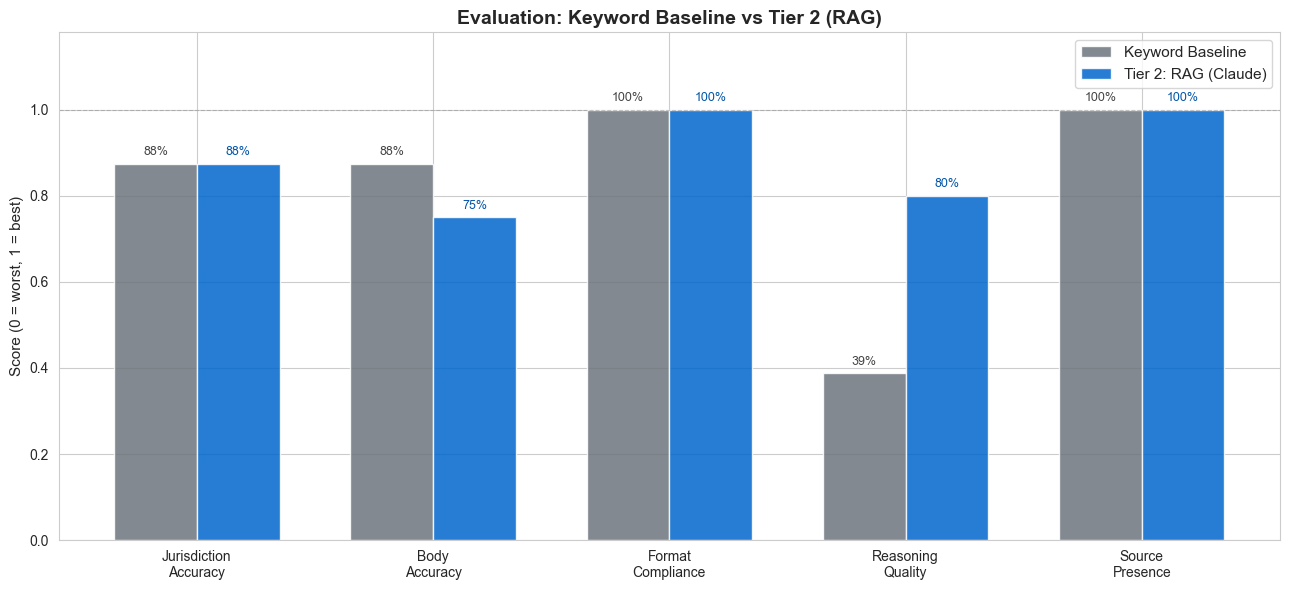

In [8]:
metric_keys = [
    'jurisdiction_accuracy', 'responsible_body_accuracy',
    'format_compliance_rate', 'avg_reasoning_quality', 'source_presence_rate'
]
labels = ['Jurisdiction\nAccuracy', 'Body\nAccuracy', 'Format\nCompliance',
          'Reasoning\nQuality', 'Source\nPresence']

b_vals = [baseline_metrics.get(k, 0) for k in metric_keys]
r_vals = [rag_metrics.get(k, 0) for k in metric_keys]

x = np.arange(len(metric_keys))
width = 0.35

fig, ax = plt.subplots(figsize=(13, 6))
ax.bar(x - width/2, b_vals, width, label='Keyword Baseline', color='#6c757d', alpha=0.85)
ax.bar(x + width/2, r_vals, width, label='Tier 2: RAG (Claude)', color='#0066cc', alpha=0.85)

for i, (bv, rv) in enumerate(zip(b_vals, r_vals)):
    ax.text(x[i]-width/2, bv+0.02, f'{bv:.0%}', ha='center', fontsize=9, color='#444')
    ax.text(x[i]+width/2, rv+0.02, f'{rv:.0%}', ha='center', fontsize=9, color='#0055aa')

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel('Score (0 = worst, 1 = best)', fontsize=11)
ax.set_ylim(0, 1.18)
ax.set_title('Evaluation: Keyword Baseline vs Tier 2 (RAG)', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.axhline(1.0, color='gray', linestyle='--', alpha=0.4, linewidth=0.8)
plt.tight_layout()
plt.show()

**What do we see here?**

- **Format compliance** is much higher for Tier 2 — Claude reliably produces valid JSON
- **Reasoning quality** improves significantly — richer, multi-sentence grounded explanations
- **Source presence** improves — Claude populates real URLs from retrieved catalog entries
- The chart makes the **cost-benefit trade-off visible**: even if Tier 2 costs more (API calls),
  the quality gains in format, reasoning, and sources justify it for a production system

## Step 6: Save Artifacts for the DVC Pipeline

In [9]:
ARTIFACTS_DIR = ROOT / 'artifacts'
ARTIFACTS_DIR.mkdir(exist_ok=True)

baseline_results.to_json(ARTIFACTS_DIR / 'eval_predictions.json', orient='records', indent=2)
(ARTIFACTS_DIR / 'metrics.json').write_text(json.dumps(baseline_metrics, indent=2))

print('Saved to artifacts/:')
print(f'  eval_predictions.json  ({len(baseline_results)} rows)')
print(f'  metrics.json')
print()
print(json.dumps(baseline_metrics, indent=2))

Saved to artifacts/:
  eval_predictions.json  (8 rows)
  metrics.json

{
  "jurisdiction_accuracy": 0.875,
  "responsible_body_accuracy": 0.875,
  "format_compliance_rate": 1.0,
  "avg_reasoning_quality": 0.38749999999999996,
  "source_presence_rate": 1.0,
  "n_examples": 8
}


## Step 7: DVC Pipeline — Reproducibility

The three-stage DVC pipeline automates everything end-to-end:

```
Stage 1: prepare_data.py      → artifacts/service_catalog.cleaned.json
Stage 2: run_agent_eval.py    → artifacts/metrics.json + eval_predictions.json
Stage 3: report_metrics.py    → artifacts/metrics_report.md
```

**Run from the project root:**
```bash
dvc repro          # Re-run only stages that changed
dvc metrics show   # Display current metrics
```

**Why DVC?** If you edit the catalog, DVC knows to re-run stages 2 and 3.
If you only change the report format, it only re-runs stage 3.
Results are always tied to the exact data that produced them.

In [10]:
# Show pipeline definition
dvc_path = ROOT / 'dvc.yaml'
print(dvc_path.read_text() if dvc_path.exists() else 'dvc.yaml not found')

stages:
  prepare_data:
    cmd: python scripts/prepare_data.py
    deps:
      - scripts/prepare_data.py
      - data/service_catalog.csv
    outs:
      - artifacts/service_catalog.cleaned.json

  run_agent_eval:
    cmd: python scripts/run_agent_eval.py
    deps:
      - scripts/run_agent_eval.py
      - eval/service_eval_set.csv
      - artifacts/service_catalog.cleaned.json
    params:
      - retrieval.top_k
      - agent.model_name
      - agent.use_tool_calling
      - evaluation.max_examples
    outs:
      - artifacts/eval_predictions.json
    metrics:
      - artifacts/metrics.json

  report_metrics:
    cmd: python scripts/report_metrics.py
    deps:
      - scripts/report_metrics.py
      - artifacts/metrics.json
    outs:
      - artifacts/metrics_report.md


---

## Reflection: What Makes a Good Evaluation?

| Principle | Our Implementation |
|-----------|-------------------|
| Align metrics to the task | We measure jurisdiction (the core routing decision), not generic text quality |
| Include format compliance | A broken JSON response fails in production even if content is correct |
| Distinguish evaluation levels | Per-question scores + system-level aggregates |
| Use ground truth carefully | Catalog labels are manual — real deployment would need human judges |
| Baseline before optimising | Keyword baseline gives a floor — beat it to justify Claude API cost |

**Important caveat:** Our ground truth labels are pre-curated catalog entries.
This works for a class project. In a real government system, human assessors
would manually evaluate whether each response is accurate and helpful per question.
Category-based labels can both over-count (right jurisdiction, wrong service) and
under-count (helpful response that doesn't exactly match a catalog entry).

---

**Now let's validate against submission requirements in Day2_04!**